## Imports

In [1]:
import math
from copy import deepcopy

import matplotlib.pyplot as plt
import numpy as np
import torch.nn as nn
import torch.optim as optim
from hyperopt import STATUS_OK, Trials, fmin, hp, space_eval, tpe
from hyperopt.pyll import scope
from pybeamline.mappers.print_operator import print_operator
from pybeamline.sources import BEvent
from river.tree import HoeffdingAdaptiveTreeClassifier
from sklearn.metrics import accuracy_score, f1_score

from models.darwin import DARWINClassifier
from utils.experiment import load_config
from utils.streaming.drift_detector import NoDriftDetector
from utils.streaming.factories import create_dataset, create_model, create_transformer
from utils.streaming.maps import EmptyMap, NextActivityEmitterMap
from utils.streaming.pipelines import (
    BEventSource,
    TaskPipeline,
)
from utils.streaming.sinks import ClassificationEvaluatorSink, EmptySink
from utils.streaming.transformers import DARWINTransformer, IndexBasedTransformer

c:\Users\Pavel\Desktop\PROJECTS\master-thesis\.venv\lib\site-packages\hyperopt\atpe.py:19: UserWarning: pkg_resources is deprecated as an API. See https://setuptools.pypa.io/en/latest/pkg_resources.html. The pkg_resources package is slated for removal as early as 2025-11-30. Refrain from using this package or pin to Setuptools<81.
  import pkg_resources


## Test Pipeline

In [2]:
from utils.streaming.pipelines import PipelineMode, SourceMode


class TestPipeline(TaskPipeline):
    def __init__(self, model, transformer, end_events, predict_only=False):
        super().__init__(
            model=model,
            transformer=transformer,
            end_events=end_events,
            pipeline_mode=PipelineMode.PREDICT_AND_LEARN,
            source_mode=SourceMode.BEVENTS,
        )
        self.predict_only = predict_only

    def get_emitter(self):
        return NextActivityEmitterMap(self.transformer, end_events=self.end_events)

    def get_sink(self):
        return ClassificationEvaluatorSink()
        return EmptySink()

    def run(self, bevents: list[BEvent]):
        source_obj = BEventSource()
        source = source_obj.get_source(bevents=bevents)

        emitter = self.get_emitter()
        predictor = self.get_predictor()
        learner = self.get_learner()
        sink = self.get_sink()

        source.pipe(
            emitter,
            # print_operator(
            #     'EMIT> trace_id={0[0]}, features={0[1]}, y_true={0[2]}'
            # ),
            predictor,
            print_operator(
                'PREDICT> trace_id={0[0]}, features={0[1]}, y_true={0[2]}, y_pred={0[3]}'
            )
            if self.predict_only
            else EmptyMap(),
            learner if not self.predict_only else EmptyMap(),
        ).sink(sink)

        df = sink.to_dataframe()

        return df, self.model

In [3]:
EVENTS = [
    ('ABCDEF', 10000),
    # ('GHIJKL', 10000),
]

unique_events = {event for trace, count in EVENTS for event in trace}
end_events = {event for trace, count in EVENTS for event in trace[-1]}

print(f'Unique events: {unique_events}')
print(f'End events: {end_events}')

bevents = []
_case_id = 0
for i, (trace, count) in enumerate(EVENTS):
    for j in range(count):
        _case_id += 1
        for event in trace:
            bevents.append(BEvent(event, _case_id, 'Test process'))

Unique events: {'F', 'B', 'D', 'A', 'E', 'C'}
End events: {'F'}


## Manual experiment

In [17]:
model = HoeffdingAdaptiveTreeClassifier(
    drift_detector=NoDriftDetector(),
    grace_period=100,
    delta=0.001,
    tau=0.05,
    split_criterion='info_gain',
    leaf_prediction='nba',
    nb_threshold=10,
    max_depth=20,
    seed=42,
)

transformer = IndexBasedTransformer(
    max_events=6,
    include_prefix_len=False
)

pipeline = TestPipeline(
    model=model, transformer=transformer, end_events=end_events
)
results_df, model = pipeline.run(bevents)

NameError: name 'TestPipeline' is not defined

In [14]:
darwin_model = DARWINClassifier(
    embedding_dim=4,
    w2v_window=5,
    sequence_window=6,
    optimizer_cls=lambda p: optim.NAdam(p, lr=0.001),
    loss_fn=nn.CrossEntropyLoss(),
    lstm_layers=2,
    hidden_dim=32,
    dropout=0,
    batch_size=32,
    dynamic_n_classes=True,
    n_classes=len(unique_events),
    max_n_classes=20,
    drift_detector=NoDriftDetector(),
    epochs=10,
    # early_stop_patience=5,
    init_size=len(bevents) * 0.1,
    end_events=end_events,
)

darwin_transformer = DARWINTransformer()

pipeline = TestPipeline(
    model=darwin_model, transformer=darwin_transformer, end_events=end_events
)
darwin_results_df, darwin_model = pipeline.run(bevents)

Initialization completed
600 events processed
Initial vocabulary size: 5
{'D', 'B', 'E', 'F', 'C'}


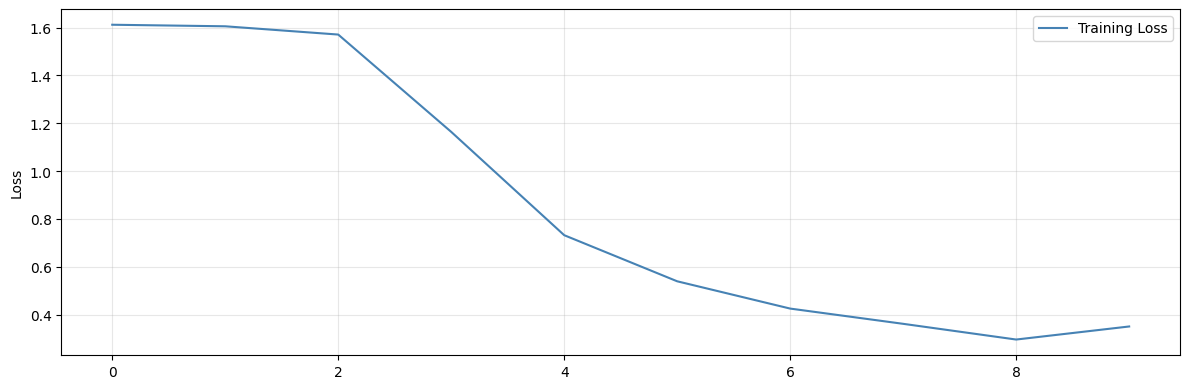

In [15]:
if hasattr(darwin_model, 'loss_history'):
    _, ax = plt.subplots(figsize=(12, 4))

    ax.plot(
        darwin_model.loss_history,
        label='Training Loss',
        color='steelblue',
        linewidth=1.5,
    )
    ax.grid(True, alpha=0.3)
    ax.set_xlabel('')
    ax.set_ylabel('Loss')
    ax.legend(loc='best')

    plt.tight_layout()

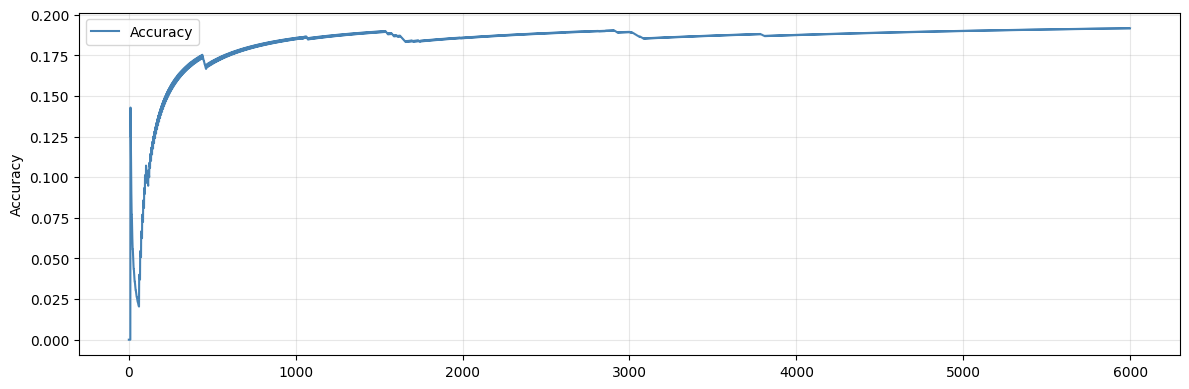

In [7]:
_, ax = plt.subplots(figsize=(12, 4))
ax.plot(
    results_df['accuracy'],
    label='Accuracy',
    color='steelblue',
    linewidth=1.5,
)
ax.grid(True, alpha=0.3)
ax.set_xlabel('')
ax.set_ylabel('Accuracy')
ax.legend(loc='best')
plt.tight_layout()

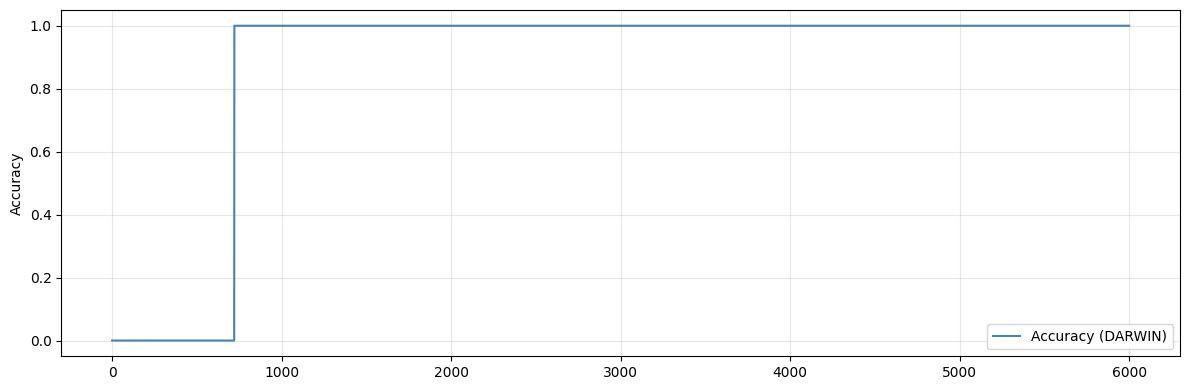

In [16]:
_, ax = plt.subplots(figsize=(12, 4))
ax.plot(
    darwin_results_df['accuracy'],
    label='Accuracy (DARWIN)',
    color='steelblue',
    linewidth=1.5,
)
ax.grid(True, alpha=0.3)
ax.set_xlabel('')
ax.set_ylabel('Accuracy')
ax.legend(loc='best')
plt.tight_layout()

In [9]:
results_df.tail()

,trace_id,y_true,y_pred,n_pred,n_drifts,drift_detected,trace_n,prefix_len,accuracy,macro_f1
5995,1000,B,D,4994,0,False,1000,2,0.191630,0.144341
5996,1000,C,D,4995,0,False,1000,3,0.191592,0.144312
5997,1000,D,D,4996,0,False,1000,4,0.191753,0.144383
5998,1000,E,D,4997,0,False,1000,5,0.191715,0.144350
5999,1000,F,D,4998,0,False,1000,6,0.191677,0.144335


In [12]:
darwin_results_df.tail()

,trace_id,y_true,y_pred,n_pred,n_drifts,drift_detected,trace_n,prefix_len,accuracy,macro_f1
5995,1000,B,B,4396,0,False,1000,2,1.0,1.0
5996,1000,C,C,4397,0,False,1000,3,1.0,1.0
5997,1000,D,D,4398,0,False,1000,4,1.0,1.0
5998,1000,E,E,4399,0,False,1000,5,1.0,1.0
5999,1000,F,F,4400,0,False,1000,6,1.0,1.0


In [13]:
predict_bevents = [BEvent(event, 'unseen', 'Test process') for event in 'ABCDEF']

predict_pipeline = TestPipeline(
    model=model,
    transformer=transformer,
    end_events=end_events,
    predict_only=True,
)
predict_results_df, _ = predict_pipeline.run(predict_bevents)

PREDICT> trace_id=unseen, features={'act_0': 'A'}, y_true=A, y_pred=D
PREDICT> trace_id=unseen, features={'act_0': 'B', 'act_1': 'A'}, y_true=B, y_pred=D
PREDICT> trace_id=unseen, features={'act_0': 'C', 'act_1': 'B', 'act_2': 'A'}, y_true=C, y_pred=D
PREDICT> trace_id=unseen, features={'act_0': 'D', 'act_1': 'C', 'act_2': 'B', 'act_3': 'A'}, y_true=D, y_pred=D
PREDICT> trace_id=unseen, features={'act_0': 'E', 'act_1': 'D', 'act_2': 'C', 'act_3': 'B', 'act_4': 'A'}, y_true=E, y_pred=D
PREDICT> trace_id=unseen, features={}, y_true=F, y_pred=None


In [13]:
darwin_predict_pipeline = TestPipeline(
    model=darwin_model,
    transformer=darwin_transformer,
    end_events=end_events,
    predict_only=True,
)
darwin_predict_results_df, _ = darwin_predict_pipeline.run(predict_bevents)

PREDICT> trace_id=unseen, features={'case_id': 'unseen', 'event': 'A', 'event_id': 12001}, y_true=A, y_pred=B
PREDICT> trace_id=unseen, features={'case_id': 'unseen', 'event': 'B', 'event_id': 12002}, y_true=B, y_pred=C
PREDICT> trace_id=unseen, features={'case_id': 'unseen', 'event': 'C', 'event_id': 12003}, y_true=C, y_pred=D
PREDICT> trace_id=unseen, features={'case_id': 'unseen', 'event': 'D', 'event_id': 12004}, y_true=D, y_pred=E
PREDICT> trace_id=unseen, features={'case_id': 'unseen', 'event': 'E', 'event_id': 12005}, y_true=E, y_pred=F
PREDICT> trace_id=unseen, features={}, y_true=F, y_pred=None


## Plots

In [ ]:
_, ax = plt.subplots(figsize=(12, 4))

plot_df = (
    results_df.dropna(subset=['y_pred'])
    .sort_values('n_pred')
    .reset_index(drop=True)
    .copy()
)

ax.plot(
    plot_df['macro_f1'],
    label='Macro F1-score',
    color='steelblue',
    linewidth=1.5,
)
ax.grid(True, alpha=0.3)
ax.set_ylim(0, 1.1)
ax.set_title('Macro F1-score over stream predictions')
ax.set_xlabel('Prediction #')
ax.legend(loc='best')

In [ ]:
_, ax = plt.subplots(figsize=(12, 4))

grouped_df = (
    plot_df.groupby('trace_id')
    .agg({'macro_f1': 'mean'})
    .sort_values('trace_id')
    .reset_index()
    .copy()
)

ax.plot(
    grouped_df['macro_f1'],
    label='Macro F1-score',
    color='steelblue',
    linewidth=1.5,
)
ax.grid(True, alpha=0.3)
ax.set_ylim(0, 1.1)
ax.set_title('Macro F1-score averaged over traces')
ax.set_xlabel('Trace #')
ax.legend(loc='best')

In [ ]:
_, ax = plt.subplots(figsize=(12, 4))

window_size = 100
center_window = True
metric = 'f1'
# metric = 'accuracy'


def get_windowed_metric(
    df,
    window_size,
    center_window,
    metric='f1',
    group_by=None,
    agg='mean',
    **metric_kwargs,
):
    y_true = np.asarray(df['y_true'])
    y_pred = np.asarray(df['y_pred'])

    metric_map = {
        'f1': lambda yt, yp: f1_score(
            yt, yp, average='macro', zero_division=0, **metric_kwargs
        ),
        'accuracy': lambda yt, yp: accuracy_score(yt, yp, **metric_kwargs),
    }
    metric_fn = metric_map[metric]

    n = len(y_true)
    scores = np.empty(n, dtype=float)

    if center_window:
        left = window_size // 2
        right = window_size - left
        for i in range(n):
            start = max(0, i - left)
            end = min(n, i + right)
            scores[i] = metric_fn(y_true[start:end], y_pred[start:end])
    else:
        for i in range(n):
            start = max(0, i - window_size + 1)
            end = i + 1
            scores[i] = metric_fn(y_true[start:end], y_pred[start:end])

    if group_by is None:
        return scores

    out = df.copy()
    metric_col = f'windowed_{metric}'
    out[metric_col] = scores

    grouped = out.groupby(group_by, dropna=False)[metric_col].agg(agg).reset_index()

    return grouped[metric_col].values


windowed_df = plot_df.sort_values(['trace_n', 'n_pred']).reset_index(drop=True).copy()

metric_values = get_windowed_metric(
    windowed_df,
    window_size=window_size,
    center_window=center_window,
    metric=metric,
)

ax.plot(
    metric_values,
    label=f'{metric.capitalize()}',
    color='steelblue',
    linewidth=1.5,
)
ax.grid(True, alpha=0.3)
ax.set_ylim(0, 1.1)
ax.set_title(
    f'{metric.capitalize()} windowed (window={window_size}, center={center_window})'
)
ax.set_xlabel('Prediction #')
ax.legend(loc='best')

In [ ]:
_, ax = plt.subplots(figsize=(12, 4))

trace_metric_values = get_windowed_metric(
    windowed_df,
    window_size=window_size,
    center_window=center_window,
    metric=metric,
    group_by='trace_id',
    agg='mean',
)

ax.plot(
    trace_metric_values,
    label=f'{metric.capitalize()}',
    color='steelblue',
    linewidth=1.5,
)
ax.grid(True, alpha=0.3)
ax.set_ylim(0, 1.1)
ax.set_title(
    f'{metric.capitalize()} windowed (window={window_size}, center={center_window}) averaged over traces'
)
ax.set_xlabel('Trace #')
ax.legend(loc='best')

## Hyperparameter optimization

In [3]:
def get_hyperopt_space(cfg, prefix=''):
    space = {}

    def process_value(key, value):
        if isinstance(value, dict):
            if 'search' in value:
                search_type = str(value['search']).lower()
                is_exp = bool(value.get('exp', False))
                is_log = bool(value.get('log', False))
                base = float(value.get('base', 2))

                if is_exp and is_log:
                    raise ValueError(f"Use only one of 'exp' or 'log' for '{key}'.")

                if search_type == 'choice':
                    opts = value['options']
                    proc_opts = [
                        process_value(f'{key}__opt{i}', opt)
                        if isinstance(opt, dict)
                        else opt
                        for i, opt in enumerate(opts)
                    ]
                    return hp.choice(key, proc_opts)

                if search_type in ('int', 'float'):
                    low, high = value['low'], value['high']
                    is_int = search_type == 'int'

                    # EXP scale
                    if is_exp:
                        if is_int:
                            e = scope.int(
                                hp.quniform(f'{key}__exp', int(low), int(high), 1)
                            )
                            return scope.int(scope.pow(base, e))
                        else:
                            e = hp.uniform(f'{key}__exp', float(low), float(high))
                            return scope.pow(base, e)

                    # LOG scale
                    if is_log:
                        low_f, high_f = float(low), float(high)
                        if low_f <= 0 or high_f <= 0:
                            raise ValueError(
                                f"Log scale requires low/high > 0 for '{key}'."
                            )
                        if is_int:
                            return scope.int(
                                hp.loguniform(key, math.log(low_f), math.log(high_f))
                            )
                        else:
                            return hp.loguniform(key, math.log(low_f), math.log(high_f))

                    # LINEAR scale
                    if is_int:
                        return scope.int(hp.quniform(key, int(low), int(high), 1))
                    else:
                        return hp.uniform(key, float(low), float(high))

                raise ValueError(f"Unsupported search type '{search_type}' at '{key}'.")

            # Nested node
            return {k: process_value(f'{key}_{k}', v) for k, v in value.items()}

        return value

    for key, value in cfg.items():
        space[key] = process_value(f'{prefix}_{key}' if prefix else key, value)

    return space

In [4]:
def run_hyperopt(cfg):
    cfg = deepcopy(cfg)

    task_cfg = cfg.pop('task', {})
    task = task_cfg.get('type', None)
    mode = task_cfg.get('mode', None)

    dataset_cfg = cfg.pop('dataset', {})
    dataset_kwargs, dataset_source, end_events = create_dataset(dataset_cfg)

    transformer_cfg = cfg.get('transformer', {})

    model_cfg = cfg.get('model', {})

    search_cfg = cfg.pop('search', {})
    max_trials = search_cfg.get('max_trials', None)
    metric = search_cfg.get('metric', None)
    seed = int(search_cfg.get('seed', 123))

    model_space = get_hyperopt_space(model_cfg)
    transformer_space = get_hyperopt_space(
        transformer_cfg,
        prefix='transformer',
    )

    hyperopt_space = {
        'model_cfg': model_space,
        'transformer_cfg': transformer_space,
    }

    trials = Trials()

    def objective(sample):
        _model_cfg = sample['model_cfg']
        _transformer_cfg = sample['transformer_cfg']

        _model = create_model(_model_cfg)
        _transformer = create_transformer(_transformer_cfg)

        # TODO: pipeline should be created using factory
        _pipeline = TestPipeline(
            model=_model,
            transformer=_transformer,
            end_events=end_events,
            predict_only=False,
        )

        _results_df, _model = _pipeline.run(**dataset_kwargs)

        _pred_df = _results_df.dropna(subset=['y_pred'])

        _valid_score = _pred_df[metric].iloc[-1]

        return {
            'loss': -_valid_score,  # minimize negative score
            'score': _valid_score,
            'status': STATUS_OK,
            'model_cfg': _model_cfg,
            'transformer_cfg': _transformer_cfg,
        }

    best_raw = fmin(
        fn=objective,
        space=hyperopt_space,
        algo=tpe.suggest,
        max_evals=max_trials,
        trials=trials,
        rstate=np.random.default_rng(seed),
    )

    best_all = space_eval(hyperopt_space, best_raw)

    best_model_cfg = best_all['model_cfg']
    best_transformer_cfg = best_all['transformer_cfg']

    return {
        'best_raw': best_raw,
        'best_model_cfg': best_model_cfg,
        'best_transformer_cfg': best_transformer_cfg,
        'trials': trials,
    }

In [5]:
def get_top_models(hyperopt_results, k=5):
    trials_obj = hyperopt_results['trials']

    rows = []
    for t in trials_obj.trials:
        res = t.get('result', {})

        if res.get('status') != 'ok':
            continue

        loss = res.get('loss')
        score = res.get('score', None)
        rows.append(
            {
                'trial_id': t.get('tid'),
                'loss': loss,
                'score': score,
                'model_cfg': res.get('model_cfg'),
                'transformer_cfg': res.get('transformer_cfg'),
            }
        )

    rows = [r for r in rows if r['loss'] is not None]
    rows.sort(key=lambda x: x['loss'])

    top = rows[:k]
    print(f'Top {len(top)} trials')
    print('================================')
    for i, r in enumerate(top, 1):
        print('score:', r['score'])
        print('model_cfg:', r['model_cfg'])
        print('transformer_cfg:', r['transformer_cfg'])
        print('================================')

    return top

In [7]:
yaml_config_path = 'C:/Users/Pavel/Desktop/PROJECTS/master-thesis/conf/experiments/streaming/aht/synthetic_hypersearch.yaml'
# yaml_config_path = 'C:/Users/Pavel/Desktop/PROJECTS/master-thesis/conf/experiments/streaming/darwin/synthetic_hypersearch.yaml'

cfg = load_config(yaml_config_path)

hyperopt_results = run_hyperopt(cfg)

100%|██████████| 200/200 [01:42<00:00,  1.95trial/s, best loss: -0.6465014046274477]


In [8]:
top_results = get_top_models(hyperopt_results, k=5)

Top 5 trials
score: 0.6465014046274477
model_cfg: {'params': {'delta': 0.009843129419526078, 'drift_detector': {'type': 'none'}, 'grace_period': 143, 'leaf_prediction': 'nba', 'max_depth': 13, 'nb_threshold': 8, 'seed': 42, 'split_criterion': 'info_gain', 'switch_significance': 0.0288075736331818, 'tau': 0.09854693880405375}, 'type': 'aht'}
transformer_cfg: {'include_prefix_len': False, 'max_events': 4, 'type': 'dim'}
score: 0.6252278607892467
model_cfg: {'params': {'delta': 0.008930961853600691, 'drift_detector': {'type': 'none'}, 'grace_period': 69, 'leaf_prediction': 'nba', 'max_depth': 16, 'nb_threshold': 9, 'seed': 42, 'split_criterion': 'info_gain', 'switch_significance': 0.044448393951044184, 'tau': 0.09974912947839605}, 'type': 'aht'}
transformer_cfg: {'include_prefix_len': False, 'max_events': 4, 'type': 'dim'}
score: 0.6219637499679395
model_cfg: {'params': {'delta': 0.008391709207391084, 'drift_detector': {'type': 'none'}, 'grace_period': 200, 'leaf_prediction': 'nba', 'max_

In [ ]:
# 1) cfg save to yaml
# 2) loss as metric for neural networks